## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
out_dir = project_dir / "out"

In [2]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

from calculate_metrics import calculate_metrics_ret
from noise_pert import set_seed

andes.config_logger(stream_level=30)

In [3]:
# base case file
case_path = test_case_dir / "regf2_testbench.xlsx"
pert_file = project_dir / "noise_pert.py"

## Run TDS Sweep

In [4]:
# anything w/o units is in p.u. 
metrics = pd.DataFrame({
    "Tr (s)": [], 
    "Seed":[],
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[]
})

# save a few time-series for visualization
#M_series_final = pd.DataFrame({
#})

In [5]:
step_time = 0.001

# run at STEP_TIME = 0.001s
Tr_vals = np.linspace(0.002, 0.05, 25)
H_rec_vals = np.linspace(0.002, 0.05, 7)

#Tr_vals = np.linspace(0.002, 0.05, 3)
#H_rec_vals = np.linspace(0.002, 0.05, 3)

seed_vals = np.arange(0, 10)
#seed_vals = np.arange(0, 2)


print(Tr_vals)
print()
print(H_rec_vals)
print()
print(seed_vals)

[0.002 0.004 0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02  0.022 0.024
 0.026 0.028 0.03  0.032 0.034 0.036 0.038 0.04  0.042 0.044 0.046 0.048
 0.05 ]

[0.002 0.01  0.018 0.026 0.034 0.042 0.05 ]

[0 1 2 3 4 5 6 7 8 9]


In [6]:
metrics = metrics.iloc[0:0]
Path("mc_results").mkdir(exist_ok=True)

for tr in Tr_vals:
    base_case = andes.get_case(case_path)
    record_M = tr in H_rec_vals

    # accumulate this Tr's long-format records here, flush once per Tr
    tr_records = []

    for seed_idx in seed_vals:
        ss = andes.load(base_case, setup=False, pert=pert_file)
        ss.REGF2.set('Tr', 1, tr)
    
        set_seed(seed_idx)
        if (tr >= 0.02):
            step_time = 0.01

        print(f"Running TDS for Tr = {ss.REGF2.Tr.v}, seed_idx = {seed_idx}, step time = {step_time}. Recording = {record_M}")

        ss.setup()
        ss.config.warn_abnormal = 1
        ss.PFlow.run()

        ss.TDS.config.tstep = step_time

        ss.TDS.config.tf = 7 # 2s after disturbance
        ss.TDS.config.fixt = 1 # fixed time step
        ss.TDS.config.no_tqdm = 1
        ss.TDS.config.criteria = 1
        ss.TDS.run()

        # scalar metrics — unchanged, one row per (tr, seed) trial
        row, M_t = calculate_metrics_ret(ss)
        row["Tr (s)"] = tr
        row["Seed"] = seed_idx

        metrics = pd.concat([metrics, row], axis=0) # attach row

        # long-format time series — only for the Tr values you're recording
        if record_M:
            Psen_t = ss.TDS.get_timeseries(ss.REGF2.Psen_y).loc[5.1:6]
            trial_df = pd.DataFrame({
                'tr': tr,
                'seed': seed_idx,
                't': M_t.index,
                'H': M_t.values,
                'Psen_y': Psen_t.values[:,0],   # assumes same index/length as M_t
            })
            tr_records.append(trial_df)

    # checkpoint this Tr's data to its own Parquet file, then free memory
    if record_M and tr_records:
        tr_df = pd.concat(tr_records, ignore_index=True)
        tr_df.to_parquet(f"mc_results/tr_{tr:.4f}.parquet", index=False)
        del tr_records, tr_df   # free memory before the next Tr

    # also checkpoint scalar metrics after every Tr, in case of a later crash
    metrics.to_parquet("mc_results/metrics.parquet", index=False)

print("All done!")

rng set to: 0
Running TDS for Tr = [np.float64(0.002)], seed_idx = 0, step time = 0.001. Recording = True
rng set to: 1
Running TDS for Tr = [np.float64(0.002)], seed_idx = 1, step time = 0.001. Recording = True
rng set to: 2
Running TDS for Tr = [np.float64(0.002)], seed_idx = 2, step time = 0.001. Recording = True
rng set to: 3
Running TDS for Tr = [np.float64(0.002)], seed_idx = 3, step time = 0.001. Recording = True
rng set to: 4
Running TDS for Tr = [np.float64(0.002)], seed_idx = 4, step time = 0.001. Recording = True
rng set to: 5
Running TDS for Tr = [np.float64(0.002)], seed_idx = 5, step time = 0.001. Recording = True
rng set to: 6
Running TDS for Tr = [np.float64(0.002)], seed_idx = 6, step time = 0.001. Recording = True
rng set to: 7
Running TDS for Tr = [np.float64(0.002)], seed_idx = 7, step time = 0.001. Recording = True
rng set to: 8
Running TDS for Tr = [np.float64(0.002)], seed_idx = 8, step time = 0.001. Recording = True
rng set to: 9
Running TDS for Tr = [np.float64

In [ ]:
Psen_t

,1
5.100000,0.271323
5.100100,0.269949
5.100200,0.268642
5.101200,0.270285
5.102200,0.270475
...,...
5.996867,0.798891
5.997867,0.812942
5.998867,0.819540
5.999867,0.825853


In [27]:
M_t

5.100000    10.616559
5.100100    10.584122
5.100200    10.552299
5.101200    10.248702
5.102200     9.961715
              ...    
5.996867     7.317094
5.997867     7.327853
5.998867     7.338583
5.999867     7.349222
6.000000     7.350632
Length: 973, dtype: float64

In [ ]:
"""
metrics = metrics.iloc[0:0]

for tr in Tr_vals:
    # load a new case
    base_case = andes.get_case(case_path)

    M_series_each_tr = pd.DataFrame({})
    Psen_series_each_tr = pd.DataFrame({})

    # for each random generator seed
    for seed_idx in seed_vals:
        ss = andes.load(base_case, setup=False, pert=pert_file)
        
        # change Tr
        ss.REGF2.set('Tr', 1, tr) # independent variable
        record_M = tr in H_rec_vals
    
        set_seed(seed_idx)
        print(f"Running TDS for Tr = {ss.REGF2.Tr.v}, seed_idx = {seed_idx}. Recording = {record_M}")

        # TDS
        ss.setup()
        ss.config.warn_abnormal = 1
        ss.PFlow.run()

        ss.TDS.config.tf = 7 # to 2s after disturbance
        ss.TDS.config.fixt = 1 # fixed step size
        ss.TDS.config.tstep = STEP_TIME 

        ss.TDS.config.no_tqdm = 1
        ss.TDS.config.criteria = 1
        ss.TDS.run()

        # metrics
        metrics_row, M_t = calculate_metrics_ret(ss)

        # if we are recording this time series
        if record_M:
            M_series_each_tr.loc[:,str(seed_idx)] = M_t
            Psen_series_each_tr.loc[:,str(seed_idx)] = ss.TDS.get_timeseries(ss.REGF2.Psen_y)

    # store and write

print("All done!")
"""

In [52]:
metrics.to_excel(f"{project_dir}/out/isolated_controller/2_noise/metrics_sheet.xlsx")

## Aggregation

In [7]:
import pandas as pd
import numpy as np

metrics = pd.read_parquet("mc_results/metrics.parquet")

# median/IQR across seeds, per Tr — robust to the heavy-tailed instability regime
scalar_agg = metrics.groupby("Tr (s)").agg(
    RMSE_median=("H_RMSE (s)", "median"),
    RMSE_q25=("H_RMSE (s)", lambda x: x.quantile(0.25)),
    RMSE_q75=("H_RMSE (s)", lambda x: x.quantile(0.75)),
    PeakPower_median=("Peak Inertial Power", "median"),
    PeakPower_q25=("Peak Inertial Power", lambda x: x.quantile(0.25)),
    PeakPower_q75=("Peak Inertial Power", lambda x: x.quantile(0.75)),
    MaxRoCoF_median=("Max RoCoF", "median"),
    MaxRoCoF_q25=("Max RoCoF", lambda x: x.quantile(0.25)),
    MaxRoCoF_q75=("Max RoCoF", lambda x: x.quantile(0.75)),
    Nadir_median=("Nadir", "median"),
    Nadir_q25=("Nadir", lambda x: x.quantile(0.25)),
    Nadir_q75=("Nadir", lambda x: x.quantile(0.75)),
    n=("H_RMSE (s)", "count"),
).reset_index()

scalar_agg.to_parquet("mc_results/scalar_agg.parquet", index=False)

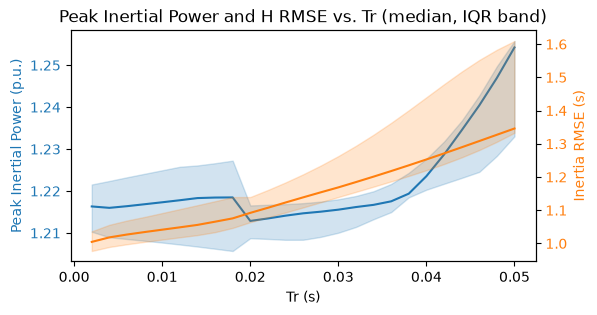

In [8]:
fig, ax1 = plt.subplots(figsize=(6, 3))
ax1.set_title("Peak Inertial Power and H RMSE vs. Tr (median, IQR band)")

color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Peak Inertial Power (p.u.)', color=color)
ax1.plot(scalar_agg["Tr (s)"], scalar_agg["PeakPower_median"], color=color)
ax1.fill_between(scalar_agg["Tr (s)"], scalar_agg["PeakPower_q25"],
                  scalar_agg["PeakPower_q75"], color=color, alpha=0.2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Inertia RMSE (s)', color=color)
ax2.plot(scalar_agg["Tr (s)"], scalar_agg["RMSE_median"], color=color)
ax2.fill_between(scalar_agg["Tr (s)"], scalar_agg["RMSE_q25"],
                  scalar_agg["RMSE_q75"], color=color, alpha=0.2)
ax2.tick_params(axis='y', labelcolor=color)

In [9]:
from pathlib import Path

COMMON_STEP = 0.01   # coarsest grid you used; downsample finer trials to match

all_files = list(Path("mc_results").glob("tr_*.parquet"))
resampled = []

for f in all_files:
    df = pd.read_parquet(f)
    tr_val = df['tr'].iloc[0]
    t_common = np.arange(df['t'].min(), df['t'].max(), COMMON_STEP)

    for seed, g in df.groupby('seed'):
        g = g.sort_values('t')
        H_interp = np.interp(t_common, g['t'], g['H'])
        Psen_interp = np.interp(t_common, g['t'], g['Psen_y'])
        resampled.append(pd.DataFrame({
            'tr': tr_val, 'seed': seed, 't': t_common,
            'H': H_interp, 'Psen_y': Psen_interp
        }))

long_df = pd.concat(resampled, ignore_index=True)
long_df.to_parquet("mc_results/long_resampled.parquet", index=False)

ts_agg = long_df.groupby(['tr', 't']).agg(
    H_median=('H', 'median'),
    H_q25=('H', lambda x: x.quantile(0.25)),
    H_q75=('H', lambda x: x.quantile(0.75)),
).reset_index()

(4.0, 8.0)

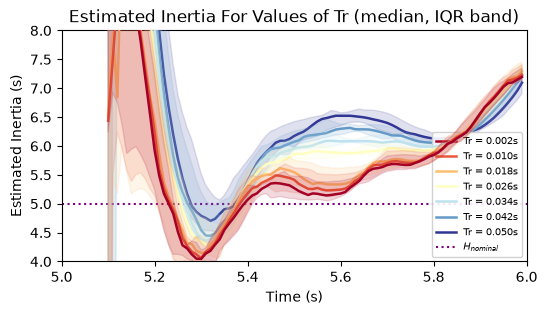

In [30]:
M_gfm = 5
time_invalid = 1 + step_time * 20

cmap = plt.cm.RdYlBu
tr_list = sorted(ts_agg['tr'].unique())

fig, ax = plt.subplots(figsize=(6, 3))

for i, tr_val in enumerate(tr_list):
    if (i % 1 == 0) and (tr_val <= 0.05):
        color = cmap(i / max(len(tr_list) - 1, 1))
        sub = ts_agg[ts_agg['tr'] == tr_val]
        ax.plot(sub['t'], sub['H_median'], color=color, linewidth=1.8,
                label=f"Tr = {tr_val:.3f}s", zorder=10 - i)
        ax.fill_between(sub['t'], sub['H_q25'], sub['H_q75'],
                         color=color, alpha=0.15, zorder=10 - i)

plt.axline((0, M_gfm), slope=0, color="purple", linestyle=":", label="$H_{nominal}$")
ax.axvspan(0, time_invalid, color='gray', alpha=0.2)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Estimated Inertia (s)")
ax.set_title("Estimated Inertia For Values of Tr (median, IQR band)")
ax.legend(loc="lower right", fontsize=7, framealpha=0.9)
ax.set_xlim(5, 6)
ax.set_ylim(4, 8)

,tr,t,H_median,H_q25,H_q75
0,0.002,5.10,8.921653,6.238152,13.849265
1,0.002,5.11,9.775509,6.921894,21.902490
2,0.002,5.12,11.055346,6.748383,19.192197
3,0.002,5.13,10.397758,6.368171,15.263278
4,0.002,5.14,9.792291,5.867441,12.908364
...,...,...,...,...,...
625,0.050,5.95,6.657194,6.528503,6.810244
626,0.050,5.96,6.749997,6.622689,6.908208
627,0.050,5.97,6.850249,6.706780,7.013065
628,0.050,5.98,6.960962,6.797403,7.121794


## Visualizaton

In [32]:
metrics.set_index("Tr (s)")

,Seed,Pref,Peak Inertial Power,Power Available,H_RMSE (s),Max RoCoF,Nadir
Tr (s),,,,,,,
0.002,0.0,0.2,1.191547,1.5,0.935185,0.043636,0.944476
0.002,1.0,0.2,1.234411,1.5,1.108837,0.044263,0.944833
0.002,2.0,0.2,1.198844,1.5,1.028715,0.043257,0.944364
0.002,3.0,0.2,1.219993,1.5,1.007601,0.044347,0.944780
0.002,4.0,0.2,1.214874,1.5,0.986349,0.043494,0.944827
...,...,...,...,...,...,...,...
0.050,5.0,0.2,1.260231,1.5,1.300549,0.047444,0.944533
0.050,6.0,0.2,1.251167,1.5,1.344248,0.046251,0.944037
0.050,7.0,0.2,1.254238,1.5,1.347636,0.046265,0.944963


In [33]:
metrics2 = metrics.loc[:25]
metrics2
metrics = metrics2
x_tr = metrics["Tr (s)"]

### Peak Delivered Power vs. Tr

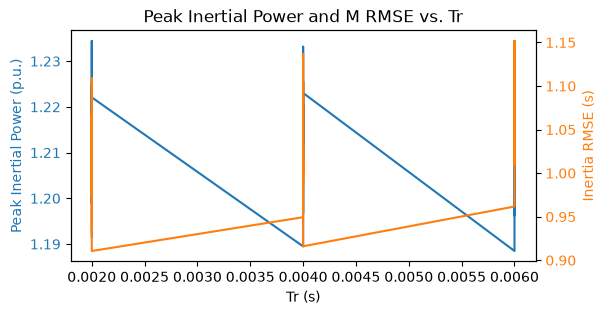

In [34]:
y_1 = metrics["Peak Inertial Power"]
y_power_avail = metrics["Power Available"]

fig, ax1 = plt.subplots(figsize=(6, 3))

ax1.set_title("Peak Inertial Power and M RMSE vs. Tr")

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Peak Inertial Power (p.u.)', color=color) # y-axis
ax1.plot(x_tr, y_1, color=color, label="Highest REGF2.Pe")
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right Side)
y_rmse = metrics["H_RMSE (s)"]

# Second Y-Axis (Left side)
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_xlabel('Tr (s)')
ax2.set_ylabel('Inertia RMSE (s)', color=color)
ax2.plot(x_tr, y_rmse, color=color)
ax2.tick_params(axis='y', labelcolor=color)


#ax1.set_xlim(0, 0.1)

### Max RoCoF and Nadir vs. Tr

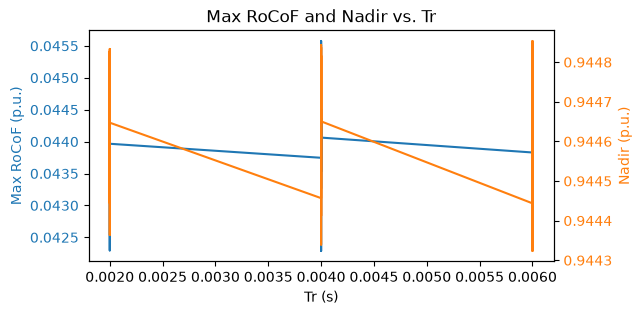

In [35]:
y_1 = metrics["Max RoCoF"]
y_2 = metrics["Nadir"]

fig, ax1 = plt.subplots(figsize=(6, 3))
ax1.set_title("Max RoCoF and Nadir vs. Tr")

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Max RoCoF (p.u.)', color=color)
ax1.plot(x_tr, y_1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right side)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Nadir (p.u.)', color=color)
ax2.plot(x_tr, y_2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()

### Plotting Estimated H Time-Series for Selected Values of Tr 

In [36]:
M_gfm = 10
time_invalid = 1 + STEP_TIME * 20

cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 3))

for i, tr_val in enumerate(M_series.columns):
    if (i % 1 == 0) and (tr_val < 0.05) :
        color = cmap(i / (len(M_series.columns) - 1))
        ax.plot(M_series.index, M_series[tr_val], color=color, linewidth=1.8,
                label=f"Tr = {tr_val:.2f}s", zorder = 10 - i)

plt.axline((0, M_gfm), slope=0, color="purple", linestyle=":", label=f"$H_{{nominal}}$")
ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
    
ax.set_xlabel("Time (s)")
ax.set_ylabel("Estimated Inertia (s)")

ax.set_title(f"Estimated Inertia For Values of Tr")
ax.legend(loc="upper right", fontsize=7, framealpha=0.9)
ax.set_xlim(5, 6)
ax.set_ylim(5, 30)

NameError: name 'STEP_TIME' is not defined

In [ ]:
M_series

In [ ]:
M_series